<a href="https://colab.research.google.com/github/japhia16/AI-Assisted-Underwriting-Triage-Agent/blob/main/Student2glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install statsmodels pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded.")

Libraries loaded.


In [3]:
from google.colab import files

print("Upload these two files:")
print("1. clean_submissions.csv       (from Student 1 -- your own file)")
print("2. india_catastrophic_risk_with_severity_scores.csv")
print()

uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Upload these two files:
1. clean_submissions.csv       (from Student 1 -- your own file)
2. india_catastrophic_risk_with_severity_scores.csv



Saving india_catastrophic_risk_with_severity_scores.csv to india_catastrophic_risk_with_severity_scores.csv
Uploaded: ['india_catastrophic_risk_with_severity_scores.csv']


In [4]:
df = pd.read_csv("clean_submissions.csv")

print("Shape:", df.shape)
print()
print("Columns:", list(df.columns))
print()
df.head(3)

Shape: (5025, 59)

Columns: ['Submission_ID', 'District', 'Building_Age_Years', 'Sum_Insured_INR', 'Number_of_Employees', 'Years_in_Business', 'Prior_Claims_Count', 'Deductible_INR', 'Risk_Score_Raw', 'Risk_Label', 'Flood_Risk_Score', 'Cyclone_Risk_Score', 'Rainfall_Risk_Score', 'Earthquake_Risk_Score', 'Occupancy_Cold Storage Facility', 'Occupancy_Educational Campus', 'Occupancy_Factory / Manufacturing Unit', 'Occupancy_Hospital / Clinic', 'Occupancy_Hotel / Resort', 'Occupancy_Office Building', 'Occupancy_Retail Store', 'Occupancy_Shopping Mall', 'Occupancy_Unknown', 'Occupancy_Warehouse', 'Occupancy_Workshop / Fabrication Unit', 'Construction_Type_Brick & Mortar', 'Construction_Type_Pre-Engineered Steel Building', 'Construction_Type_RCC (Reinforced Cement Concrete)', 'Construction_Type_Steel Frame', 'Construction_Type_Unknown', 'Industry_Type_Agro Processing', 'Industry_Type_Auto Components', 'Industry_Type_Cement & Building Materials', 'Industry_Type_Chemicals', 'Industry_Type_Cold

,Submission_ID,District,Building_Age_Years,Sum_Insured_INR,Number_of_Employees,Years_in_Business,Prior_Claims_Count,Deductible_INR,Risk_Score_Raw,Risk_Label,...,Industry_Type_Warehousing & Logistics,Sprinkler_System_No,Sprinkler_System_Unknown,Sprinkler_System_Yes,Fire_Hydrant_Onsite_No,Fire_Hydrant_Onsite_Yes,Requested_Coverage_All Risk (Comprehensive),Requested_Coverage_Fire + Burglary,Requested_Coverage_Fire Only,Requested_Coverage_Standard Fire & Special Perils
0,SUB-2024000001,Kamrup Metropolitan,-0.933185,0.590904,-1.514504,1.312393,-0.765963,-0.723960,0.6575,Medium,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,SUB-2024000002,Ranga Reddy,-0.515159,-0.641704,0.513023,0.966458,-0.765963,1.228284,0.5630,Low,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,SUB-2024000003,Debagarh,1.240553,-0.775571,-1.090885,-0.555658,-0.765963,-0.507044,0.6214,Medium,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [5]:
np.random.seed(42)

# Simulate claim count using Poisson distribution
# Higher risk score = more claims expected
lam = 0.3 + 2.0 * df["Risk_Score_Raw"]
df["Claim_Count"] = np.random.poisson(lam)

# Simulate claim severity using Gamma distribution
# Only for submissions that had at least one claim
df["Claim_Severity_INR"] = 0.0
mask = df["Claim_Count"] > 0

mean_severity = 500000 + 3000000 * df.loc[mask, "Risk_Score_Raw"]
shape = 2.0
scale = mean_severity / shape

df.loc[mask, "Claim_Severity_INR"] = np.random.gamma(
    shape, scale, size=mask.sum()
)

print("Claim count distribution:")
print(df["Claim_Count"].value_counts().sort_index())
print()
print("Severity stats (only claims that occurred):")
print(df.loc[mask, "Claim_Severity_INR"].describe().round(2))

Claim count distribution:
Claim_Count
0    1180
1    1669
2    1244
3     638
4     215
5      65
6      10
7       2
8       2
Name: count, dtype: int64

Severity stats (only claims that occurred):
count        3845.00
mean      2302003.88
std       1665293.87
min         18826.97
25%       1077137.46
50%       1906954.25
75%       3093223.43
max      11211882.27
Name: Claim_Severity_INR, dtype: float64


In [6]:
# Columns that are not model inputs
drop_cols = [
    "Submission_ID", "District", "State", "Match_Type",
    "Match_Score", "Risk_Score_Raw", "Risk_Label",
    "Claim_Count", "Claim_Severity_INR",
    "Flood_Percent_Area", "Seismic_Zone",
    "Seismic_Risk_Level", "Cyclone_Exposure"
]

drop_cols = [c for c in drop_cols if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]

print(f"Number of features: {len(feature_cols)}")
print()
print("Feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Number of features: 55

Feature list:
  1. Building_Age_Years
  2. Sum_Insured_INR
  3. Number_of_Employees
  4. Years_in_Business
  5. Prior_Claims_Count
  6. Deductible_INR
  7. Flood_Risk_Score
  8. Cyclone_Risk_Score
  9. Rainfall_Risk_Score
  10. Earthquake_Risk_Score
  11. Occupancy_Cold Storage Facility
  12. Occupancy_Educational Campus
  13. Occupancy_Factory / Manufacturing Unit
  14. Occupancy_Hospital / Clinic
  15. Occupancy_Hotel / Resort
  16. Occupancy_Office Building
  17. Occupancy_Retail Store
  18. Occupancy_Shopping Mall
  19. Occupancy_Unknown
  20. Occupancy_Warehouse
  21. Occupancy_Workshop / Fabrication Unit
  22. Construction_Type_Brick & Mortar
  23. Construction_Type_Pre-Engineered Steel Building
  24. Construction_Type_RCC (Reinforced Cement Concrete)
  25. Construction_Type_Steel Frame
  26. Construction_Type_Unknown
  27. Industry_Type_Agro Processing
  28. Industry_Type_Auto Components
  29. Industry_Type_Cement & Building Materials
  30. Industry_Type_

In [7]:
X_sm = sm.add_constant(X)

freq_model = sm.GLM(
    df["Claim_Count"],
    X_sm,
    family=sm.families.Poisson(
        link=sm.families.links.Log()
    )
).fit(maxiter=200)

print(freq_model.summary())

with open("freq_model.pkl", "wb") as f:
    pickle.dump(freq_model, f)

print("\nFrequency model saved as freq_model.pkl")

                 Generalized Linear Model Regression Results                  
Dep. Variable:            Claim_Count   No. Observations:                 5025
Model:                            GLM   Df Residuals:                     4975
Model Family:                 Poisson   Df Model:                           49
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7577.9
Date:                Tue, 23 Jun 2026   Deviance:                       5677.1
Time:                        02:30:42   Pearson chi2:                 4.80e+03
No. Iterations:                   200   Pseudo R-squ. (CS):            0.03232
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [8]:
# Only train on rows that had at least one claim
severity_df = df[df["Claim_Count"] > 0].copy()
X_sev = sm.add_constant(severity_df[feature_cols])

sev_model = sm.GLM(
    severity_df["Claim_Severity_INR"],
    X_sev,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
).fit(maxiter=200)

print(sev_model.summary())

with open("sev_model.pkl", "wb") as f:
    pickle.dump(sev_model, f)

print("\nSeverity model saved as sev_model.pkl")

                 Generalized Linear Model Regression Results                  
Dep. Variable:     Claim_Severity_INR   No. Observations:                 3845
Model:                            GLM   Df Residuals:                     3795
Model Family:                   Gamma   Df Model:                           49
Link Function:                    Log   Scale:                         0.47953
Method:                          IRLS   Log-Likelihood:                -59669.
Date:                Tue, 23 Jun 2026   Deviance:                       2049.1
Time:                        02:31:17   Pearson chi2:                 1.91e+03
No. Iterations:                   200   Pseudo R-squ. (CS):            0.04454
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Binary: High risk = 1, Low/Medium = 0
y_risk = (df["Risk_Label"] == "High").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)

risk_model = LogisticRegression(max_iter=1000)
risk_model.fit(X_train, y_train)

print("Risk Score Model Results:")
print(classification_report(y_test, risk_model.predict(X_test)))

with open("risk_model.pkl", "wb") as f:
    pickle.dump(risk_model, f)

print("Risk model saved as risk_model.pkl")

Risk Score Model Results:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       771
           1       0.90      0.84      0.87       234

    accuracy                           0.94      1005
   macro avg       0.93      0.90      0.91      1005
weighted avg       0.94      0.94      0.94      1005

Risk model saved as risk_model.pkl


In [10]:
X_with_const = sm.add_constant(X)

freq_pred = freq_model.predict(X_with_const)
sev_pred  = sev_model.predict(X_with_const)

df["freq_pred"]        = freq_pred.values
df["sev_pred"]         = sev_pred.values
df["GLM_Pure_Premium"] = (freq_pred * sev_pred).values

print("Pure Premium stats:")
print(df["GLM_Pure_Premium"].describe().round(2))

df.to_csv("submissions_with_premium.csv", index=False)
print("\nSaved: submissions_with_premium.csv")

Pure Premium stats:
count       5025.00
mean     3405712.39
std       976912.40
min      1422706.29
25%      2686159.47
50%      3265248.65
75%      3996279.47
max      8523821.81
Name: GLM_Pure_Premium, dtype: float64

Saved: submissions_with_premium.csv


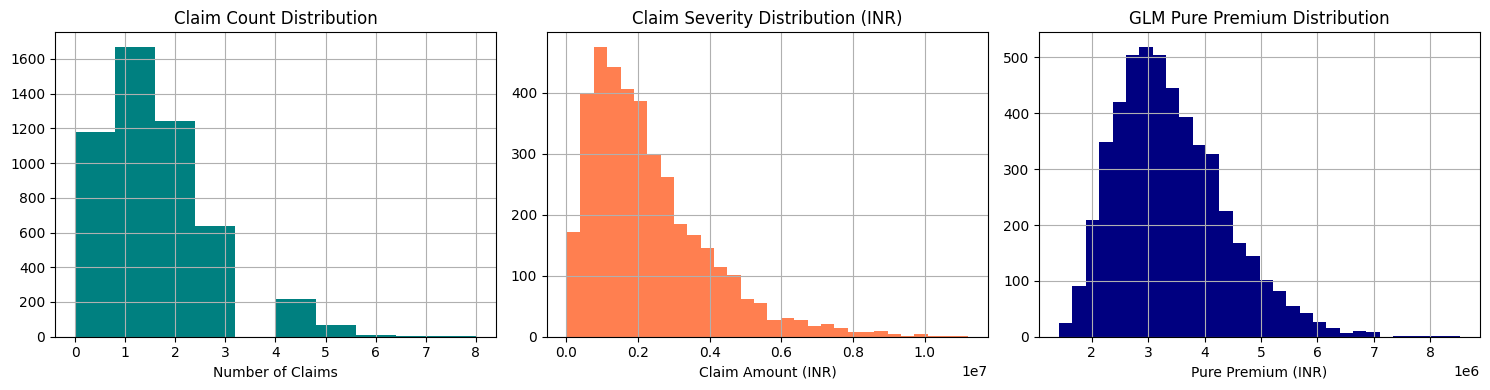

Saved: student2_validation_plots.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["Claim_Count"].hist(ax=axes[0], bins=10, color="teal")
axes[0].set_title("Claim Count Distribution")
axes[0].set_xlabel("Number of Claims")

df.loc[df["Claim_Count"] > 0, "Claim_Severity_INR"].hist(
    ax=axes[1], bins=30, color="coral"
)
axes[1].set_title("Claim Severity Distribution (INR)")
axes[1].set_xlabel("Claim Amount (INR)")

df["GLM_Pure_Premium"].hist(ax=axes[2], bins=30, color="navy")
axes[2].set_title("GLM Pure Premium Distribution")
axes[2].set_xlabel("Pure Premium (INR)")

plt.tight_layout()
plt.savefig("student2_validation_plots.png", dpi=150)
plt.show()
print("Saved: student2_validation_plots.png")

In [12]:
from google.colab import files
import os

download_files = [
    "freq_model.pkl",
    "sev_model.pkl",
    "risk_model.pkl",
    "submissions_with_premium.csv",
    "student2_validation_plots.png"
]

print("Downloading files...")
for fname in download_files:
    if os.path.exists(fname):
        files.download(fname)
        print(f"  Downloaded: {fname}")
    else:
        print(f"  MISSING: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: freq_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: submissions_with_premium.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: student2_validation_plots.png


In [13]:
print("Save this notebook to GitHub:")
print()
print("File → Save a copy in GitHub")
print("Repo: japhia16/AI-Assisted-Underwriting-Triage-Agent")
print("Path: student2/student2_glm_models.ipynb")
print()
print("Also upload to student2/ folder on GitHub:")
print("  student2_validation_plots.png")
print()
print("Upload pkl files to models/ folder on GitHub:")
print("  freq_model.pkl")
print("  sev_model.pkl")
print("  risk_model.pkl")
print()
print("Upload submissions_with_premium.csv to data/ folder on GitHub.")

Save this notebook to GitHub:

File → Save a copy in GitHub
Repo: japhia16/AI-Assisted-Underwriting-Triage-Agent
Path: student2/student2_glm_models.ipynb

Also upload to student2/ folder on GitHub:
  student2_validation_plots.png

Upload pkl files to models/ folder on GitHub:
  freq_model.pkl
  sev_model.pkl
  risk_model.pkl

Upload submissions_with_premium.csv to data/ folder on GitHub.
